# NLP project-EMAIL classifier as Spam/Ham

In [2]:
import nltk

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import pandas as pd

In [5]:
mes_df= pd.read_csv("C:\\Users\\student\\Downloads\\spam.csv")

In [6]:
mes_df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


* no preprocessing needed

In [7]:
mes_df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [8]:
mes_df["length"]=mes_df["Message"].apply(len)

In [9]:
mes_df.head()

,Category,Message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns 


<Axes: ylabel='Frequency'>

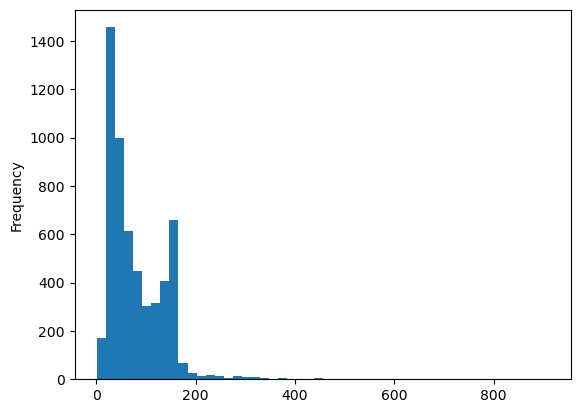

In [11]:
mes_df['length'].plot(bins = 50, kind='hist')

In [12]:
messages = [line.rstrip() for line in open("C:\\Users\\student\\Downloads\\spam.csv")]
print(len(messages))

5575


In [13]:
for message_no, message in enumerate(messages[:10]):
  print(message_no, message)
  print('\n')

0 Category,Message


1 ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."


2 ham,Ok lar... Joking wif u oni...


3 spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


4 ham,U dun say so early hor... U c already then say...


5 ham,"Nah I don't think he goes to usf, he lives around here though"


6 spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv"


7 ham,Even my brother is not like to speak with me. They treat me like aids patent.


8 ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


9 spam,WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim 

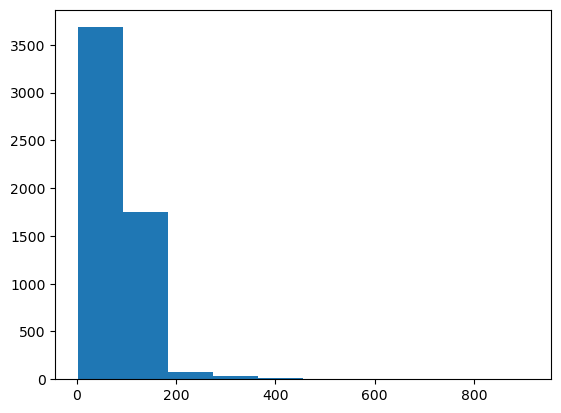

In [14]:
plt.hist(mes_df['length'])
plt.show()

In [15]:
from string import punctuation
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords

In [17]:
# preprocess text 
def text_process(mess):
    nopunc = [char for char in mess if char not in punctuation] 
    nopunc = ''.join(nopunc) 

    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]


In [18]:
eg = "hey!,.gfij;.fijvpoerk.adfoo[;#"
text_process(eg)

['heygfijfijvpoerkadfoo']

In [19]:
mes_df.head()

,Category,Message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
mes_df['Message'].head().apply(text_process)

0    [Go, jurong, point, crazy, Available, bugis, n...
1                       [Ok, lar, Joking, wif, u, oni]
2    [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3        [U, dun, say, early, hor, U, c, already, say]
4    [Nah, dont, think, goes, usf, lives, around, t...
Name: Message, dtype: object

In [24]:
from nltk import WordNetLemmatizer
lm= WordNetLemmatizer()
lm.lemmatize('discoveries')

'discovery'

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
bow_transformer =  CountVectorizer(analyzer=text_process).fit(mes_df['Message'])
print(len(bow_transformer.vocabulary_))

11422


In [26]:
msg4 = mes_df['Message'][3]
msg4

'U dun say so early hor... U c already then say...'

In [27]:
bow4 = bow_transformer.transform([msg4])
print(bow4)
print(bow4.shape)

  (0, 4066)	2
  (0, 4627)	1
  (0, 5258)	1
  (0, 6201)	1
  (0, 6219)	1
  (0, 7183)	1
  (0, 9551)	2
(1, 11422)


In [28]:
messages_bow = bow_transformer.transform(mes_df['Message']) 

print('Shape of Sparse Matrix:' , messages_bow.shape) 
print('Amount of Non-zero occurance:', messages_bow.nnz) 
print('Sparsilty value: %.2f%%',(100.0 * messages_bow.nnz / (messages_bow.shape[0] * messages_bow.shape[1])))

Shape of Sparse Matrix: (5572, 11422)
Amount of Non-zero occurance: 50500
Sparsilty value: %.2f%% 0.07934838914285262


In [29]:
#tfidf
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_transformer = TfidfTransformer().fit(messages_bow)


In [30]:
tfidf4 = tfidf_transformer.transform(bow4)
print(tfidf4)

  (0, 9551)	0.5385626262927564
  (0, 7183)	0.4389365653379857
  (0, 6219)	0.3187216892949149
  (0, 6201)	0.29953799723697416
  (0, 5258)	0.29729957405868723
  (0, 4627)	0.26619801906087187
  (0, 4066)	0.40832589933384067


In [31]:
msgs_tfidf = tfidf_transformer.transform(messages_bow) 

print(msgs_tfidf.shape)

(5572, 11422)


# Implementing Naive Bayes 

In [32]:
from sklearn.naive_bayes import MultinomialNB
spam_detect_model = MultinomialNB()
spam_detect_model.fit(msgs_tfidf, mes_df['Category'])

MultinomialNB()

In [33]:
print("predicted",spam_detect_model.predict(tfidf4)[0])


predicted ham


In [34]:
print("Expected",mes_df.Category[4])

Expected ham


In [35]:
from sklearn.metrics import classification_report  # Model Evaluation
all_predicted =spam_detect_model.predict(msgs_tfidf)
print(classification_report(mes_df['Category'],all_predicted))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      4825
        spam       1.00      0.85      0.92       747

    accuracy                           0.98      5572
   macro avg       0.99      0.92      0.95      5572
weighted avg       0.98      0.98      0.98      5572



In [36]:
from sklearn.metrics import accuracy_score, precision_score

accuracy = accuracy_score(mes_df['Category'], all_predicted)
# For multi-class or binary targets, specify the averaging method (e.g., 'weighted' or 'macro')
precision = precision_score(mes_df['Category'], all_predicted, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")


Accuracy: 0.98
Precision: 0.98


In [37]:
from sklearn.metrics import classification_report

report = classification_report(mes_df['Category'], all_predicted, output_dict=True)

accuracy = report['accuracy']
# Extraction for a specific class (e.g., 'spam')
spam_precision = report['spam']['precision']
# Extraction for overall averages
weighted_precision = report['weighted avg']['precision']

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")


Overall Accuracy: 0.9794
Weighted Precision: 0.9798
